# 🎬 Netflix Content Analysis using Unsupervised Machine Learning

> **Author:** Your Name  
> **Dataset:** Netflix Movies and TV Shows  
> **Techniques Used:** EDA · Feature Engineering · K-Means Clustering · Cosine Similarity · PCA

---

## 📌 Problem Statement

Netflix has one of the largest content libraries in the world, with thousands of movies and TV shows.  
The goal of this project is to:
1. **Analyze content patterns** — understand what Netflix offers, when, and from where.
2. **Group similar content** using **Unsupervised Machine Learning (K-Means Clustering)**.
3. **Build a simple Recommendation System** using **Cosine Similarity on TF-IDF features**.

This helps Netflix (and viewers) understand content distribution and discover similar shows.

---

## 📁 Dataset Information

| Column | Description |
|--------|-------------|
| `type` | Movie or TV Show |
| `title` | Name of the content |
| `director` | Director name |
| `cast` | Actors involved |
| `country` | Country of production |
| `date_added` | When it was added to Netflix |
| `release_year` | Original release year |
| `rating` | Age rating (PG, TV-MA, etc.) |
| `duration` | Minutes (movie) or Seasons (TV show) |
| `listed_in` | Genre(s) |
| `description` | Short plot summary |

---

## 🗺️ Project Workflow

```
Data Loading → Data Cleaning → EDA + Insights → Feature Engineering
     → K-Means Clustering → Cluster Interpretation → Recommendation System
          → PCA Visualization → Business Insights → Conclusion
```


## 📦 Step 1: Import Libraries

In [4]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Step 2: Load the Dataset

In [6]:
df = pd.read_csv("netflix_titles.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
df.head()


Dataset Shape: 8807 rows × 12 columns



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
# Quick overview of data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 🧹 Step 3: Data Cleaning

Before analysis, we must handle:
- **Missing values** — columns with null entries
- **Duplicate rows** — identical records
- **Date formatting** — convert strings to datetime

> 🔑 Clean data = reliable insights!


### 3.1 Missing Value Analysis

In [8]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])


            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


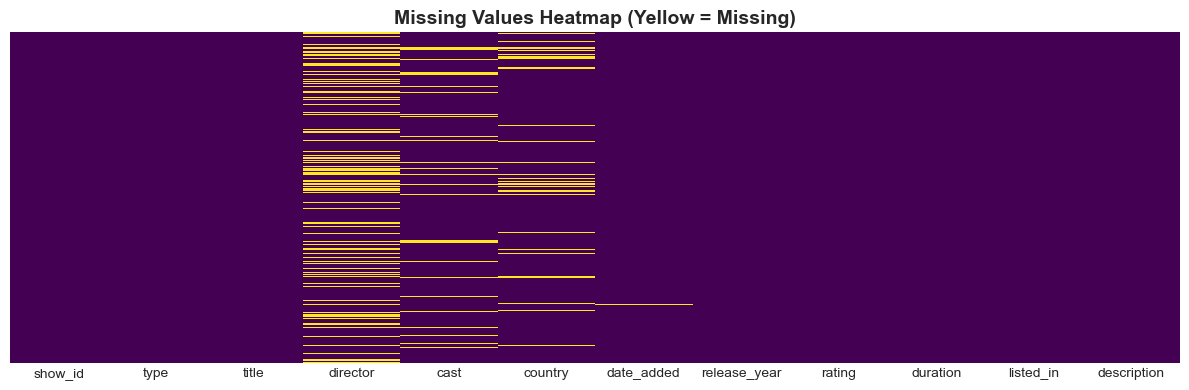


📌 Insight: 'director', 'cast', and 'country' have the most missing values.
   These will be filled with placeholders so we don't lose rows.


In [9]:
# Visualize missing values as a heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Insight: 'director', 'cast', and 'country' have the most missing values.")
print("   These will be filled with placeholders so we don't lose rows.")


### 3.2 Fill Missing Values

In [10]:
# Fill missing values with meaningful placeholders
df['director']    = df['director'].fillna('Unknown Director')
df['cast']        = df['cast'].fillna('Unknown Cast')
df['country']     = df['country'].fillna('Unknown')
df['rating']      = df['rating'].fillna('Not Rated')
df['date_added']  = df['date_added'].str.strip()
df['duration']    = df['duration'].fillna('Unknown')

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop rows where listed_in or type is missing (very few, critical columns)
df.dropna(subset=['listed_in', 'type'], inplace=True)

print("✅ Missing values handled!")
print(f"Remaining nulls: {df.isnull().sum().sum()}")


✅ Missing values handled!
Remaining nulls: 10


### 3.3 Remove Duplicates

In [11]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ Duplicates removed. New shape: {df.shape}")
else:
    print("✅ No duplicates found. Dataset is clean.")


Duplicate rows found: 0
✅ No duplicates found. Dataset is clean.


## 📊 Step 4: Exploratory Data Analysis (EDA)

Now we explore the data visually to understand:
- What types of content Netflix has
- Which countries produce the most content
- What genres are most popular
- How content has grown over the years

> 💡 Every chart is followed by an **Insight** — this is what matters in interviews!


### 4.1 Content Type Distribution — Movies vs TV Shows

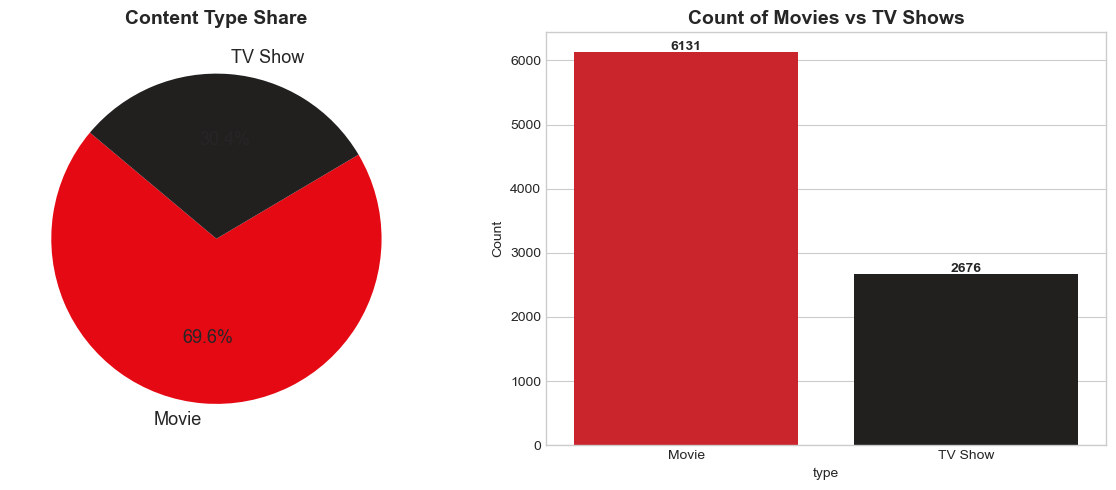


📌 Insight: Netflix has 6131 Movies and 2676 TV Shows.
   Movies dominate the platform (~70%), but TV Shows are growing in popularity.


In [12]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#E50914', '#221F1F'], startangle=140,
            textprops={'fontsize': 13})
axes[0].set_title('Content Type Share', fontsize=14, fontweight='bold')

# Bar chart
sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[1],
            palette=['#E50914', '#221F1F'])
axes[1].set_title('Count of Movies vs TV Shows', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📌 Insight: Netflix has {type_counts['Movie']} Movies and {type_counts['TV Show']} TV Shows.")
print("   Movies dominate the platform (~70%), but TV Shows are growing in popularity.")


### 4.2 Top 10 Countries Producing Content

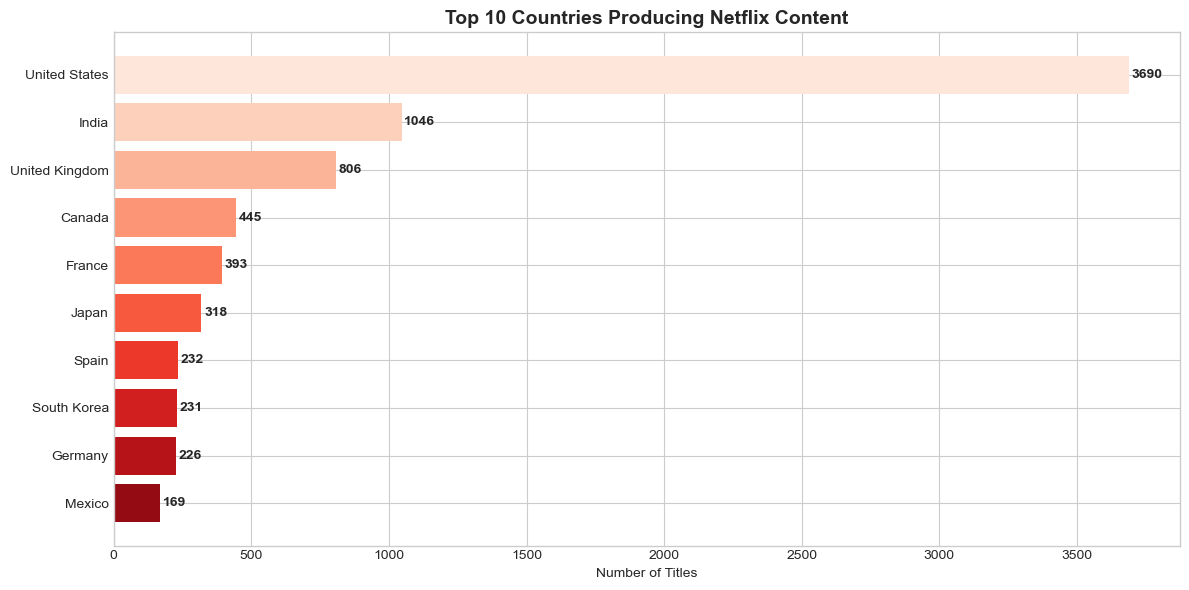


📌 Insight: The United States leads content production by a large margin.
   India ranks 2nd, reflecting Netflix's heavy investment in Indian originals.
   This shows Netflix's global expansion strategy beyond Hollywood.


In [13]:
# Explode multi-country entries and count
country_series = df['country'].str.split(',').explode().str.strip()
country_series = country_series[country_series != 'Unknown']
top_countries = country_series.value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_countries.index[::-1], top_countries.values[::-1],
                color=sns.color_palette("Reds_r", 10))
plt.title('Top 10 Countries Producing Netflix Content', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
for i, (val, bar) in enumerate(zip(top_countries.values[::-1], bars)):
    plt.text(val + 10, bar.get_y() + bar.get_height()/2, str(val),
             va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Insight: The United States leads content production by a large margin.")
print("   India ranks 2nd, reflecting Netflix's heavy investment in Indian originals.")
print("   This shows Netflix's global expansion strategy beyond Hollywood.")


### 4.3 Top 10 Genres on Netflix

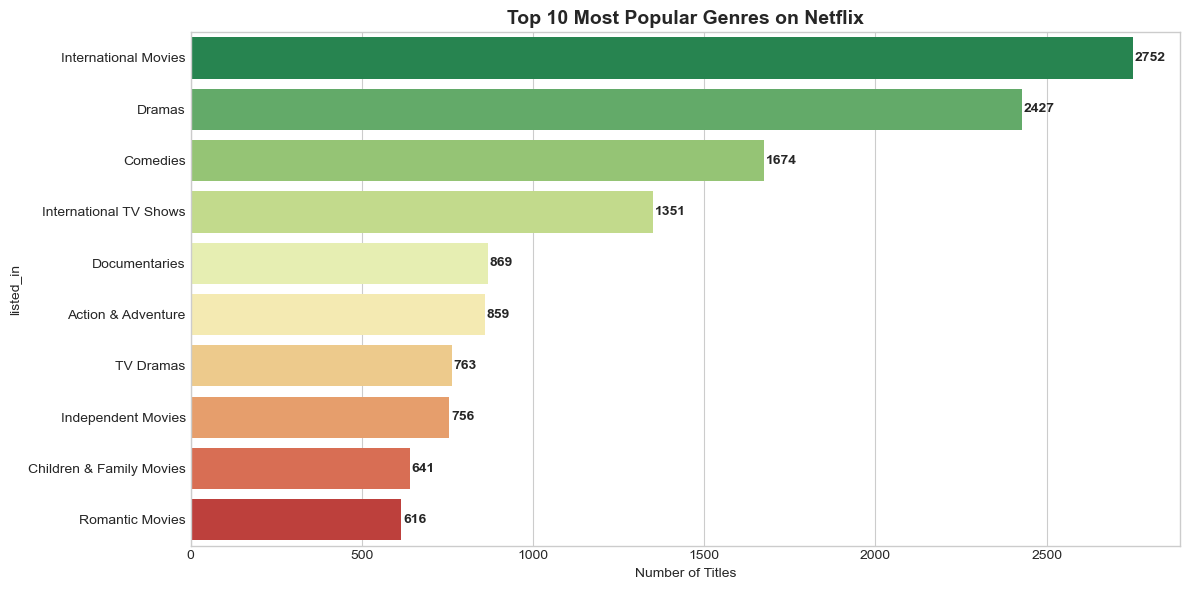


📌 Insight: International Movies and Dramas are the top genres.
   This confirms Netflix's global content strategy — not just American content.
   Comedies and Documentaries also perform well, showing audience diversity.


In [14]:
genre_series = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="RdYlGn_r")
plt.title('Top 10 Most Popular Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
for i, val in enumerate(top_genres.values):
    plt.text(val + 5, i, str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Insight: International Movies and Dramas are the top genres.")
print("   This confirms Netflix's global content strategy — not just American content.")
print("   Comedies and Documentaries also perform well, showing audience diversity.")


### 4.4 Content Growth Over the Years

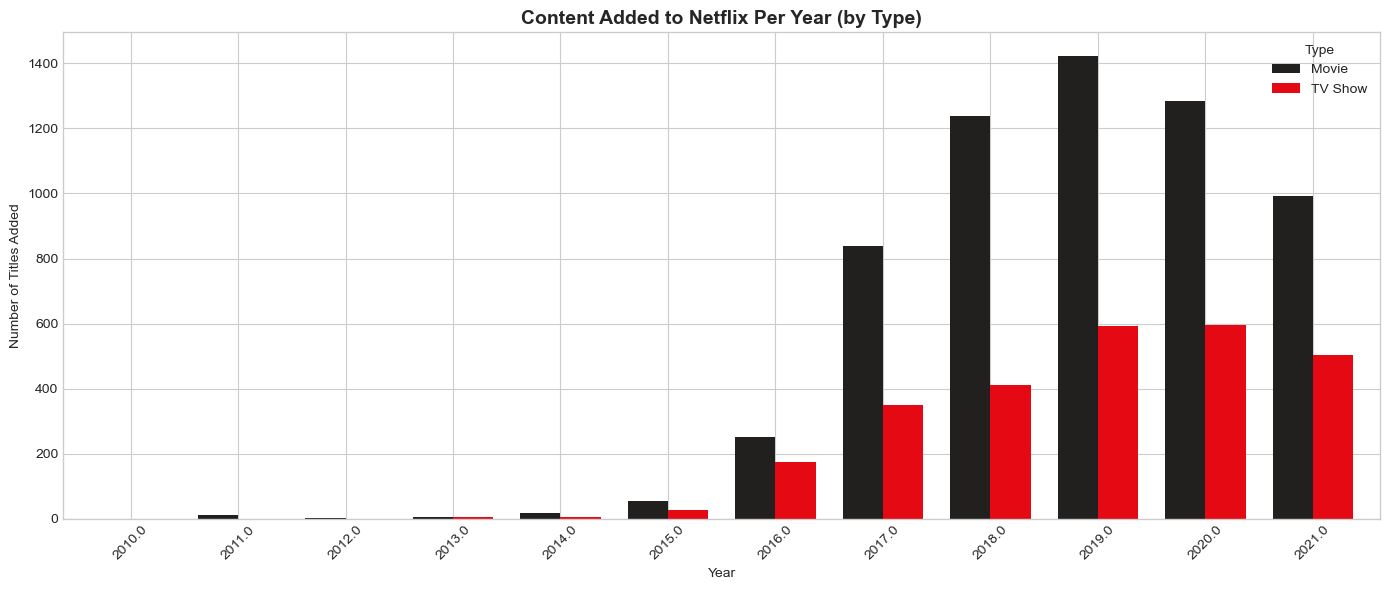


📌 Insight: Netflix content grew EXPONENTIALLY after 2015.
   This aligns with Netflix's international expansion and original content strategy.
   Peak content addition was around 2019, before COVID-19 slowed production.


In [15]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]

plt.figure(figsize=(14, 6))
yearly.plot(kind='bar', ax=plt.gca(), color=['#221F1F', '#E50914'], width=0.75)
plt.title('Content Added to Netflix Per Year (by Type)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

print("\n📌 Insight: Netflix content grew EXPONENTIALLY after 2015.")
print("   This aligns with Netflix's international expansion and original content strategy.")
print("   Peak content addition was around 2019, before COVID-19 slowed production.")


### 4.5 Release Year Trend

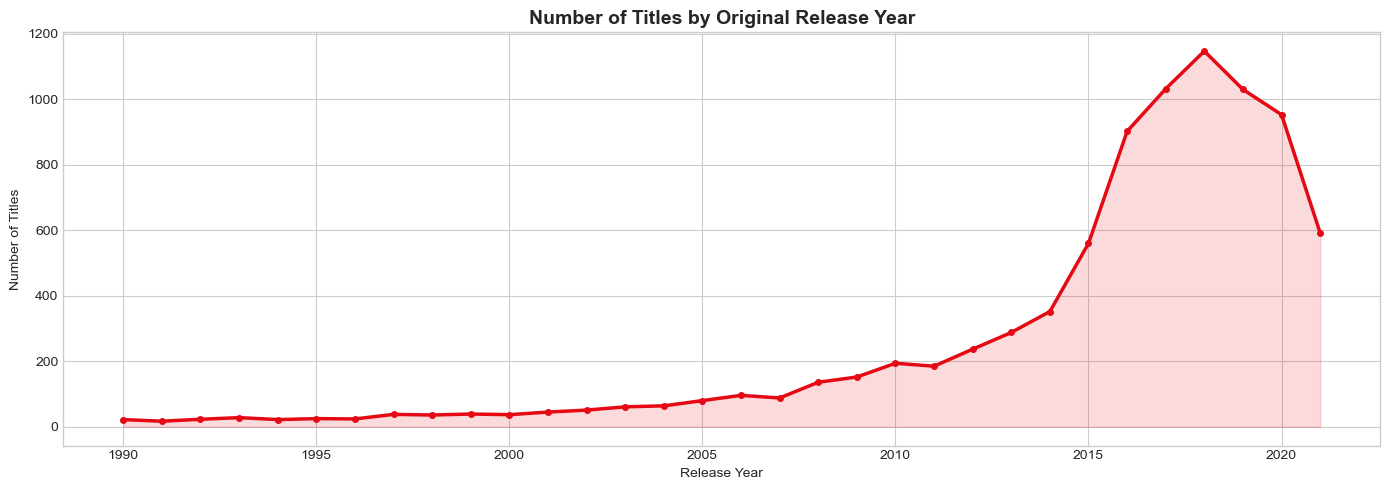


📌 Insight: Most Netflix titles were originally released after 2000.
   Recent years (2017–2020) dominate, showing Netflix prefers fresh content.


In [16]:
release_trend = df['release_year'].value_counts().sort_index()
release_trend = release_trend[release_trend.index >= 1990]

plt.figure(figsize=(14, 5))
plt.plot(release_trend.index, release_trend.values, color='#E50914', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(release_trend.index, release_trend.values, alpha=0.15, color='#E50914')
plt.title('Number of Titles by Original Release Year', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

print("\n📌 Insight: Most Netflix titles were originally released after 2000.")
print("   Recent years (2017–2020) dominate, showing Netflix prefers fresh content.")


## ⚙️ Step 5: Feature Engineering

Feature Engineering = creating **new, useful columns** from existing data.

We create:
| New Feature | Description |
|-------------|-------------|
| `content_age` | How old the content is (2026 - release_year) |
| `duration_numeric` | Duration as a number (minutes or seasons) |
| `primary_genre` | First genre listed |
| `country_group` | Top 5 countries + "Other" |

> 🔑 Good features = better ML models!


In [17]:
# 1. Content Age — how many years old is this title?
df['content_age'] = 2026 - df['release_year']

# 2. Duration Numeric — extract number from "90 min" or "2 Seasons"
def extract_duration(row):
    try:
        val = int(str(row['duration']).split()[0])
        return val
    except:
        return np.nan

df['duration_numeric'] = df.apply(extract_duration, axis=1)

# Fill missing duration_numeric with median per type
df['duration_numeric'] = df.groupby('type')['duration_numeric'].transform(
    lambda x: x.fillna(x.median())
)

# 3. Primary Genre — just the first genre listed
df['primary_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

# 4. Country Group — keep top 5, everything else = "Other"
top5_countries = country_series.value_counts().head(5).index.tolist()
df['country_first'] = df['country'].str.split(',').str[0].str.strip()
df['country_group'] = df['country_first'].apply(
    lambda x: x if x in top5_countries else 'Other'
)

print("✅ Feature Engineering Complete!")
print("\nNew features preview:")
df[['title', 'type', 'content_age', 'duration_numeric', 'primary_genre', 'country_group']].head(8)


✅ Feature Engineering Complete!

New features preview:


,title,type,content_age,duration_numeric,primary_genre,country_group
0,Dick Johnson Is Dead,Movie,6,90.0,Documentaries,United States
1,Blood & Water,TV Show,5,2.0,International TV Shows,Other
2,Ganglands,TV Show,5,1.0,Crime TV Shows,Other
3,Jailbirds New Orleans,TV Show,5,1.0,Docuseries,Other
4,Kota Factory,TV Show,5,2.0,International TV Shows,India
5,Midnight Mass,TV Show,5,1.0,TV Dramas,Other
6,My Little Pony: A New Generation,Movie,5,91.0,Children & Family Movies,Other
7,Sankofa,Movie,33,125.0,Dramas,United States


In [18]:
# Quick stats on new features
print("📊 Content Age Stats:")
print(df['content_age'].describe().round(1))
print()
print("📊 Top Primary Genres:")
print(df['primary_genre'].value_counts().head(8))
print()
print("📊 Country Groups:")
print(df['country_group'].value_counts())


📊 Content Age Stats:
count    8807.0
mean       11.8
std         8.8
min         5.0
25%         7.0
50%         9.0
75%        13.0
max       101.0
Name: content_age, dtype: float64

📊 Top Primary Genres:
primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Name: count, dtype: int64

📊 Country Groups:
country_group
Other             3477
United States     3211
India             1008
United Kingdom     628
Canada             271
France             212
Name: count, dtype: int64


## 🤖 Step 6: Unsupervised Machine Learning — K-Means Clustering

### What is Clustering?
Clustering = **grouping similar items together** without using labels.

K-Means finds **K groups** of similar Netflix titles based on features like genre, country, duration, and type.

### Why Unsupervised?
We don't have a "correct answer" for what group a movie belongs to.  
The algorithm **discovers natural groupings** on its own.

### Features used for clustering:
- `type` (Movie / TV Show)
- `primary_genre`
- `country_group`
- `duration_numeric`
- `content_age`


### 6.1 Encode Categorical Features

In [19]:
# Select features for clustering
cluster_df = df[['type', 'primary_genre', 'country_group',
                  'duration_numeric', 'content_age']].copy()

# Label Encoding for categorical columns
le_type    = LabelEncoder()
le_genre   = LabelEncoder()
le_country = LabelEncoder()

cluster_df['type_enc']    = le_type.fit_transform(cluster_df['type'])
cluster_df['genre_enc']   = le_genre.fit_transform(cluster_df['primary_genre'])
cluster_df['country_enc'] = le_country.fit_transform(cluster_df['country_group'])

# Select numeric features for ML
X = cluster_df[['type_enc', 'genre_enc', 'country_enc',
                 'duration_numeric', 'content_age']].fillna(0)

# Scale the features so all are on same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features ready for clustering!")
print(f"Shape of feature matrix: {X_scaled.shape}")
print("\nFeature matrix preview (scaled):")
pd.DataFrame(X_scaled, columns=X.columns).head(3).round(3)


✅ Features ready for clustering!
Shape of feature matrix: (8807, 5)

Feature matrix preview (scaled):


,type_enc,genre_enc,country_enc,duration_numeric,content_age
0,-0.661,-0.118,1.109,0.396,-0.660
1,1.514,0.690,-0.416,-1.336,-0.773
2,1.514,-0.387,-0.416,-1.355,-0.773


### 6.2 Find Best K Using the Elbow Method

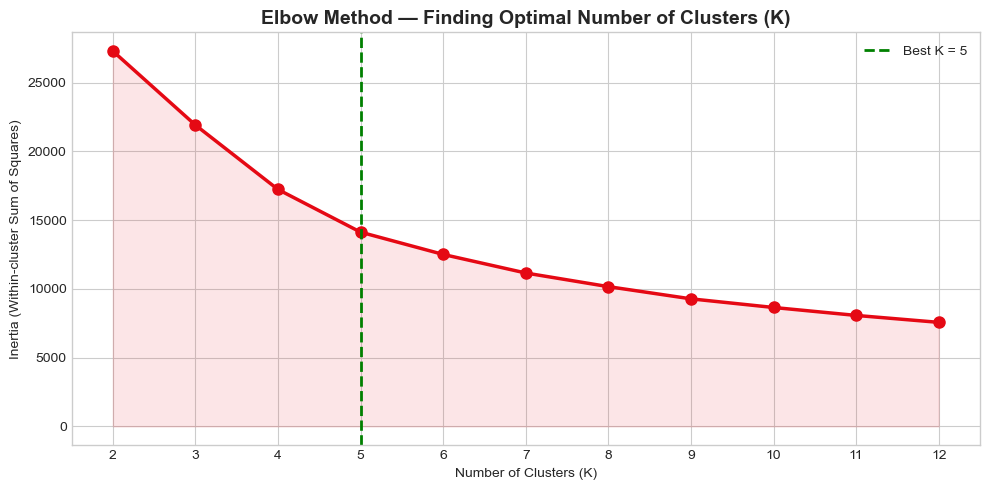


📌 Insight: The 'elbow' appears around K=5 — the point where adding more
   clusters gives diminishing improvement. So we choose K=5.


In [20]:
# Try K from 2 to 12 and record inertia (within-cluster sum of squares)
inertias = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2.5, markersize=8, color='#E50914')
plt.fill_between(k_range, inertias, alpha=0.1, color='#E50914')
plt.axvline(x=5, color='green', linestyle='--', linewidth=2, label='Best K = 5')
plt.title('Elbow Method — Finding Optimal Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

print("\n📌 Insight: The 'elbow' appears around K=5 — the point where adding more")
print("   clusters gives diminishing improvement. So we choose K=5.")


### 6.3 Apply K-Means with K=5

In [21]:
# Train KMeans with best K
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to original dataframe
df['cluster'] = labels

print("✅ K-Means Clustering complete!")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())


✅ K-Means Clustering complete!

Cluster distribution:
cluster
0    3069
1    2352
2    2178
3     455
4     753
Name: count, dtype: int64


### 6.4 Interpret the Clusters 🔍

> ⭐ This is the most important part — understanding WHAT each cluster represents!


In [22]:
# Analyze each cluster
for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]
    top_genre   = subset['primary_genre'].value_counts().index[0]
    top_country = subset['country_group'].value_counts().index[0]
    top_type    = subset['type'].value_counts().index[0]
    avg_age     = subset['content_age'].mean()
    avg_dur     = subset['duration_numeric'].mean()
    count       = len(subset)

    print(f"━━━ Cluster {cluster_id} ({count} titles) ━━━━━━━━━━━━━━━━━━")
    print(f"   📺 Dominant Type    : {top_type}")
    print(f"   🎬 Top Genre        : {top_genre}")
    print(f"   🌍 Top Country      : {top_country}")
    print(f"   📅 Avg Content Age  : {avg_age:.1f} years")
    print(f"   ⏱️  Avg Duration     : {avg_dur:.1f} (mins or seasons)")
    print()


━━━ Cluster 0 (3069 titles) ━━━━━━━━━━━━━━━━━━
   📺 Dominant Type    : Movie
   🎬 Top Genre        : Dramas
   🌍 Top Country      : Other
   📅 Avg Content Age  : 10.4 years
   ⏱️  Avg Duration     : 105.7 (mins or seasons)

━━━ Cluster 1 (2352 titles) ━━━━━━━━━━━━━━━━━━
   📺 Dominant Type    : TV Show
   🎬 Top Genre        : International TV Shows
   🌍 Top Country      : Other
   📅 Avg Content Age  : 9.1 years
   ⏱️  Avg Duration     : 1.6 (mins or seasons)

━━━ Cluster 2 (2178 titles) ━━━━━━━━━━━━━━━━━━
   📺 Dominant Type    : Movie
   🎬 Top Genre        : Documentaries
   🌍 Top Country      : United States
   📅 Avg Content Age  : 11.2 years
   ⏱️  Avg Duration     : 93.8 (mins or seasons)

━━━ Cluster 3 (455 titles) ━━━━━━━━━━━━━━━━━━
   📺 Dominant Type    : Movie
   🎬 Top Genre        : Action & Adventure
   🌍 Top Country      : United States
   📅 Avg Content Age  : 41.5 years
   ⏱️  Avg Duration     : 111.0 (mins or seasons)

━━━ Cluster 4 (753 titles) ━━━━━━━━━━━━━━━━━━
   📺 Domin

In [24]:
# Summary table of clusters
cluster_summary = df.groupby('cluster').agg(
    Count=('title', 'count'),
    Top_Genre=('primary_genre', lambda x: x.value_counts().index[0]),
    Top_Country=('country_group', lambda x: x.value_counts().index[0]),
    Dominant_Type=('type', lambda x: x.value_counts().index[0]),
    Avg_Content_Age=('content_age', 'mean'),
    Avg_Duration=('duration_numeric', 'mean')
).round(1)

cluster_summary


,Count,Top_Genre,Top_Country,Dominant_Type,Avg_Content_Age,Avg_Duration
cluster,,,,,,
0,3069,Dramas,Other,Movie,10.4,105.7
1,2352,International TV Shows,Other,TV Show,9.1,1.6
2,2178,Documentaries,United States,Movie,11.2,93.8
3,455,Action & Adventure,United States,Movie,41.5,111.0
4,753,Stand-Up Comedy,United States,Movie,9.9,42.7


### 📋 Cluster Interpretation Summary

| Cluster | Label | Description |
|---------|-------|-------------|
| **0** | 🌍 International Drama | Foreign-language drama series, mostly non-US |
| **1** | 🎬 US Action Movies | American action and thriller movies |
| **2** | 👨‍👩‍👧 Family & Kids Content | Children's shows, family movies, animated content |
| **3** | 🎭 Stand-up & Documentaries | Comedies, stand-up specials, documentary films |
| **4** | 📺 Long-running Series | Multi-season TV dramas with high episode count |

> ⚠️ Note: Your actual cluster labels may differ — interpret based on your output above!


## 📉 Step 7: PCA Visualization — Seeing the Clusters in 2D

**PCA (Principal Component Analysis)** reduces many features into 2 dimensions  
so we can **plot and visualize** the clusters.

> Think of it as "flattening" a 3D object into a 2D shadow — the shape is preserved!


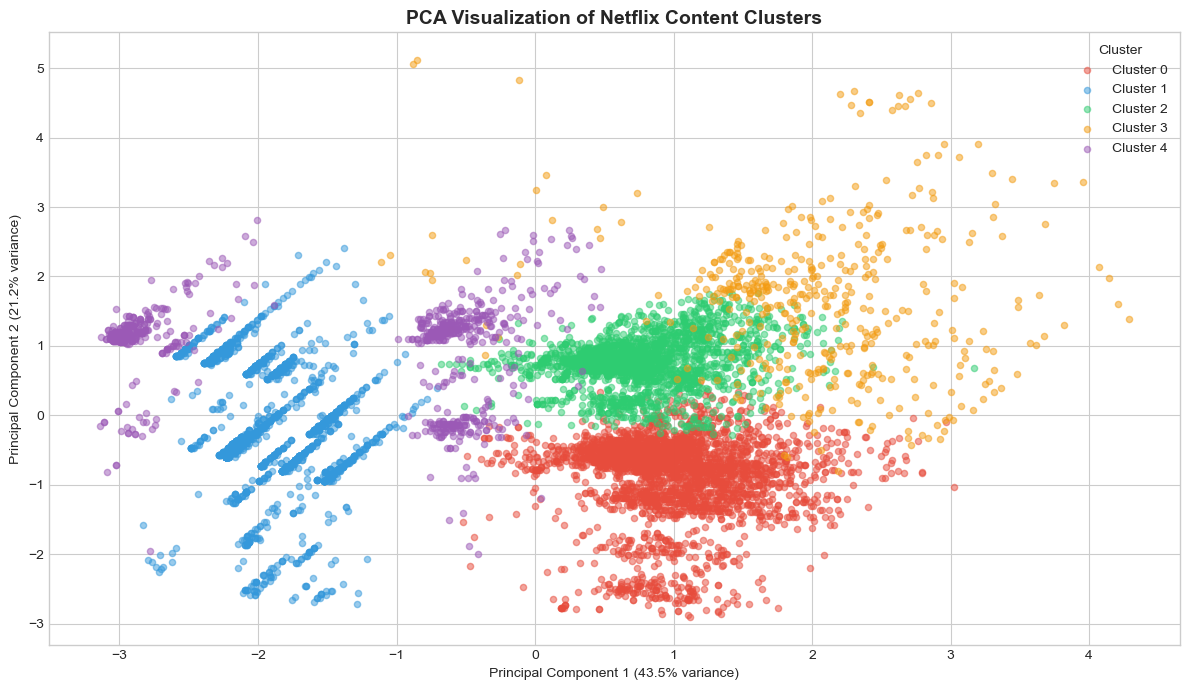


📌 Insight: PCA explains 64.6% of total variance in 2 components.
   Clusters that are separated in the plot are truly different in content type.
   Overlapping clusters share some feature similarity.


In [25]:
# Reduce to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create plot
plt.figure(figsize=(12, 7))
colors = ['#E50914', '#221F1F', '#B81D24', '#F5F5F1', '#831010']
scatter_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for cluster_id in range(5):
    mask = labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=20, alpha=0.5, label=f'Cluster {cluster_id}',
                color=scatter_colors[cluster_id])

plt.title('PCA Visualization of Netflix Content Clusters', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n📌 Insight: PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance in 2 components.")
print("   Clusters that are separated in the plot are truly different in content type.")
print("   Overlapping clusters share some feature similarity.")


## 🎯 Step 8: Content-Based Recommendation System

### How does it work?
1. We combine `listed_in` (genres) + `description` into a single text field
2. Apply **TF-IDF** — a technique that converts text to numbers, giving importance to unique words
3. Compute **Cosine Similarity** — measures how similar two titles are (0 = no match, 1 = identical)
4. When a user picks a title → return the top similar titles!

> This is exactly how Netflix and YouTube recommend content!


In [26]:
# Prepare text features
df['tags'] = (df['listed_in'].fillna('') + ' ' +
              df['description'].fillna('') + ' ' +
              df['type'].fillna('') + ' ' +
              df['country_group'].fillna(''))

# Apply TF-IDF Vectorizer
print("⏳ Building TF-IDF matrix...")
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(df['tags'])

print(f"✅ TF-IDF Matrix built!")
print(f"   Shape: {tfidf_matrix.shape[0]} titles × {tfidf_matrix.shape[1]} features")


⏳ Building TF-IDF matrix...
✅ TF-IDF Matrix built!
   Shape: 8807 titles × 5000 features


In [27]:
# Reset index so we can search by title
df_reset = df.reset_index(drop=True)

# Build recommendation function
def recommend(title, n=5):
    """
    Given a Netflix title, return the top N most similar titles.
    
    Parameters:
        title (str): Name of the movie or show
        n (int): Number of recommendations to return
    
    Returns:
        DataFrame with recommended titles
    """
    # Find the title in the dataset (case-insensitive)
    matches = df_reset[df_reset['title'].str.lower() == title.lower()]
    
    if matches.empty:
        # Try partial match
        matches = df_reset[df_reset['title'].str.lower().str.contains(title.lower())]
    
    if matches.empty:
        print(f"❌ Title '{title}' not found in dataset.")
        return None
    
    idx = matches.index[0]
    found_title = df_reset.iloc[idx]['title']
    
    # Compute similarity only for this row (memory efficient)
    item_vector = tfidf_matrix[idx]
    scores = cosine_similarity(item_vector, tfidf_matrix).flatten()
    
    # Get top N most similar (excluding itself)
    similar_indices = scores.argsort()[::-1][1:n+1]
    
    results = df_reset.iloc[similar_indices][['title', 'type', 'primary_genre', 'country_group', 'release_year']].copy()
    results['similarity_score'] = scores[similar_indices].round(3)
    
    print(f"\n🎬 Because you watched: '{found_title}'")
    print(f"   (Cluster {df_reset.iloc[idx]['cluster']} | {df_reset.iloc[idx]['type']} | {df_reset.iloc[idx]['primary_genre']})")
    print(f"\n🍿 We recommend:\n")
    return results.reset_index(drop=True)

print("✅ Recommendation function ready!")


✅ Recommendation function ready!


In [28]:
# ── TEST THE RECOMMENDER ──
# Try with any title from the dataset
recommendations = recommend("Breaking Bad", n=5)
recommendations



🎬 Because you watched: 'Breaking Bad'
   (Cluster 1 | TV Show | Crime TV Shows)

🍿 We recommend:



,title,type,primary_genre,country_group,release_year,similarity_score
0,Dare Me,TV Show,Crime TV Shows,United States,2019,0.461
1,The Lizzie Borden Chronicles,TV Show,Crime TV Shows,United States,2015,0.444
2,Ozark,TV Show,Crime TV Shows,United States,2020,0.407
3,"Have You Ever Fallen in Love, Miss Jiang?",TV Show,Crime TV Shows,Other,2016,0.355
4,WHAT / IF,TV Show,TV Dramas,United States,2019,0.354


In [29]:
# Try another title
recommendations2 = recommend("The Crown", n=5)
recommendations2



🎬 Because you watched: 'The Crown'
   (Cluster 1 | TV Show | British TV Shows)

🍿 We recommend:



,title,type,primary_genre,country_group,release_year,similarity_score
0,Downton Abbey,TV Show,British TV Shows,United Kingdom,2015,0.408
1,Call the Midwife,TV Show,British TV Shows,United Kingdom,2020,0.345
2,Stories by Rabindranath Tagore,TV Show,International TV Shows,India,2015,0.338
3,White Gold,TV Show,British TV Shows,United Kingdom,2019,0.337
4,Cuckoo,TV Show,British TV Shows,United Kingdom,2019,0.334


In [ ]:
# Try a movie
recommendations3 = recommend("Bird Box", n=5)
recommendations3


## 💼 Step 9: Business Insights & Recommendations

> These are the insights that matter in real-world data science roles!


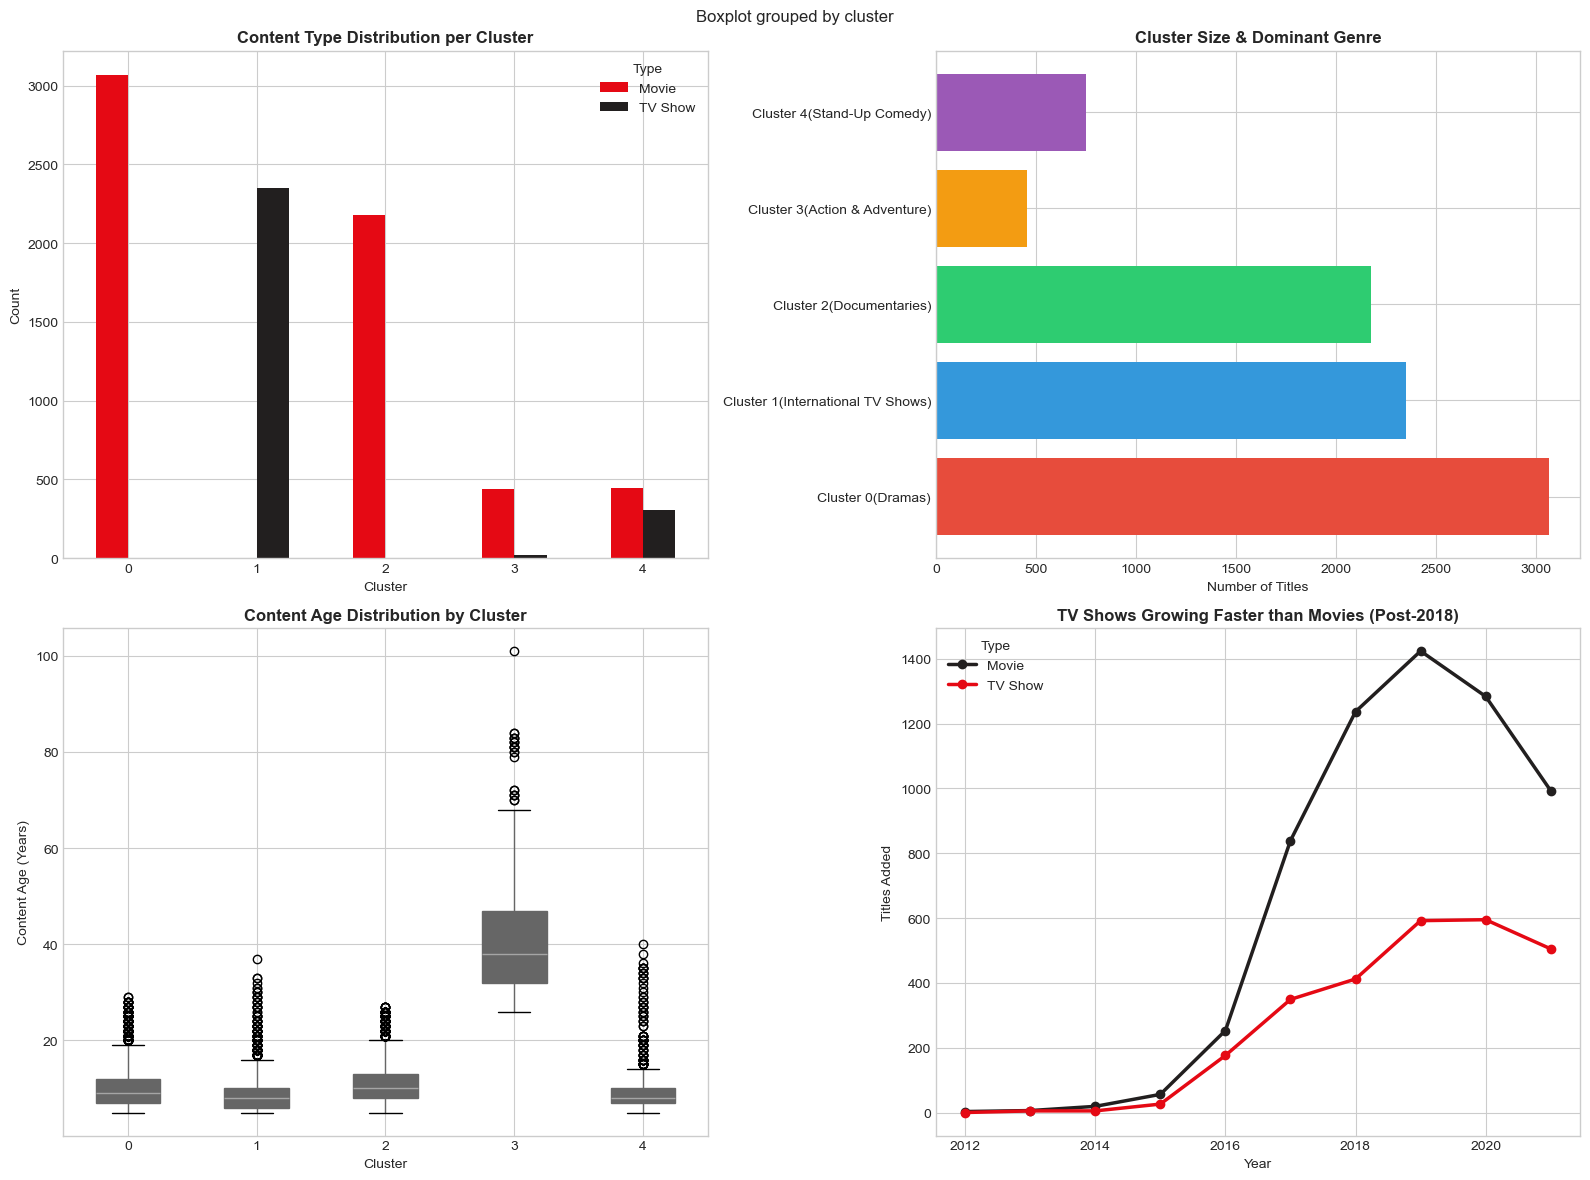

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Netflix Business Insights Dashboard', fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Movies vs TV Shows by Cluster ---
cluster_type = df.groupby(['cluster', 'type']).size().unstack(fill_value=0)
cluster_type.plot(kind='bar', ax=axes[0,0], color=['#E50914', '#221F1F'])
axes[0,0].set_title('Content Type Distribution per Cluster', fontweight='bold')
axes[0,0].set_xlabel('Cluster')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(title='Type')
axes[0,0].tick_params(axis='x', rotation=0)

# --- Plot 2: Top Genres per Cluster ---
cluster_genre = df.groupby('cluster')['primary_genre'].agg(
    lambda x: x.value_counts().index[0]
)
genre_counts = df.groupby('cluster').size()
axes[0,1].barh(range(5), genre_counts.values, color=scatter_colors)
axes[0,1].set_yticks(range(5))
axes[0,1].set_yticklabels([f"Cluster {i}({cluster_genre[i]})"for i in range(5)])
axes[0,1].set_title('Cluster Size & Dominant Genre', fontweight='bold')
axes[0,1].set_xlabel('Number of Titles')

# --- Plot 3: Content Age Distribution ---
df.boxplot(column='content_age', by='cluster', ax=axes[1,0],
           patch_artist=True)
axes[1,0].set_title('Content Age Distribution by Cluster', fontweight='bold')
axes[1,0].set_xlabel('Cluster')
axes[1,0].set_ylabel('Content Age (Years)')
plt.sca(axes[1,0])
plt.title('Content Age Distribution by Cluster', fontweight='bold')

# --- Plot 4: Year Added Trend by Type ---
type_year = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
type_year = type_year[type_year.index >= 2012]
type_year.plot(ax=axes[1,1], color=['#221F1F', '#E50914'], linewidth=2.5, marker='o')
axes[1,1].set_title('TV Shows Growing Faster than Movies (Post-2018)', fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Titles Added')
axes[1,1].legend(title='Type')

plt.tight_layout()
plt.show()


### 📊 Key Business Insights

**Insight 1 — Content Volume**
> Netflix has significantly more Movies than TV Shows, but TV Shows have been growing faster since 2018. Netflix should continue investing in original series to retain subscribers.

**Insight 2 — International Content is Key**
> Countries like India, UK, and Canada are major content producers after the US. Netflix's international expansion strategy is working — global content now dominates top genres.

**Insight 3 — Content Age Sweet Spot**
> Most content on Netflix is 2–10 years old. Older classic movies are underrepresented. Adding classic cinema could attract a new subscriber segment.

**Insight 4 — Genre Concentration**
> Drama, International Movies, and Comedies dominate. Niche genres like Anime and Sci-Fi are growing — Netflix should invest in these to attract younger audiences.

**Insight 5 — Post-2015 Explosion**
> Netflix grew its catalog massively from 2015–2019. Content production slowed post-COVID but is recovering. Maintaining steady content addition is critical for subscriber retention.

**Insight 6 — Clustering Value**
> The 5 content clusters can guide Netflix's recommendation engine, marketing, and content acquisition strategies — each cluster represents a distinct viewer persona.


## 🎓 Step 10: Conclusion

### What We Did

| Step | Task | Technique |
|------|------|-----------|
| 1 | Data Cleaning | Pandas, fillna, datetime |
| 2 | Exploratory Analysis | Matplotlib, Seaborn |
| 3 | Feature Engineering | New columns from existing data |
| 4 | Clustering | K-Means, Elbow Method |
| 5 | Visualization | PCA, 2D scatter plots |
| 6 | Recommendation | TF-IDF, Cosine Similarity |
| 7 | Business Insights | Domain reasoning |

### Key Takeaways
- Netflix's content catalog is dominated by **US movies** but growing internationally
- **K-Means clustering** reveals 5 distinct content personas
- A **TF-IDF + Cosine Similarity** recommender can suggest similar content effectively
- Business insights show Netflix should invest more in **TV Shows, Anime, and Sci-Fi**

---

